In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, get_color, get_color_and_match, get_msmhmr

from multicam.multicam import MultiCamSampling, MultiCAM

In [2]:
# stellar mass of 100 particles (should be the lowest mass we consider)
np.log10(1.4e6 * 100)

np.float64(8.146128035678238)

In [3]:
# read tree data 
hydro_data = {} 
with open("../../data/out-trees-tng100-bar.npz", 'rb') as fp:
    out = np.load(fp)
    for k in out: 
        hydro_data[k] = out[k]


In [4]:
hydro_data.keys()

dict_keys(['subfind_id', 'vpeak', 'mpeak_mah', 'is_sub', 'a12', 'mpeak_pre', 'mpeak', 'stellar_mass'])

In [5]:
# sort array by subfind ids to match with color data
_sort_mask = np.argsort(hydro_data['subfind_id'])
for k in hydro_data:
    hydro_data[k] = hydro_data[k][_sort_mask]

In [6]:
hydro_data['subfind_id']

array([      0,       1,       2, ..., 3577883, 3741554, 4263941],
      shape=(101431,))

In [7]:
# define stellar mass bin to be used throughout

stellar_mass_bin = (8.2, 8.7) # log10 Msun units 
cond1 = hydro_data['stellar_mass'] > 10**stellar_mass_bin[0]
cond2 = hydro_data['stellar_mass'] < 10**stellar_mass_bin[1]
stellar_mask = cond1 & cond2
sum(stellar_mask)

np.int64(9301)

In [8]:
# see notebook "2025-11-10 Mass bin MultiCAM Trying Mpeak"
mpeak_mass_bin = (10.4, 11.4) # log10 Msun units 

mpeak = np.log10(hydro_data['mpeak']) # min = 1e10
left_cond = mpeak > mpeak_mass_bin[0]
right_cond = mpeak < mpeak_mass_bin[1]
star_cond =hydro_data['stellar_mass'] > 0
mpeak_mask = left_cond & right_cond & star_cond
sum(mpeak_mask)

np.int64(38956)

In [9]:
# plt.hist(np.log10(hydro_data['stellar_mass'][mpeak_mask]))

In [10]:
# get colors
color_file = "../../data/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5"
colors = get_color_and_match(color_file, hydro_data['subfind_id'])
gi_color = colors['sdss_g'].values - colors['sdss_i'].values
gi_color.shape

(101431,)

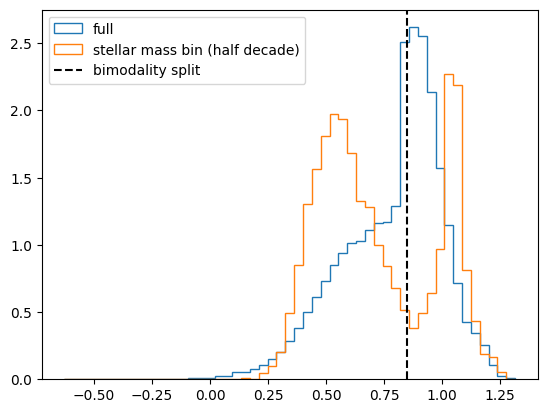

In [11]:
_, bins, _ = plt.hist(gi_color, bins=51, density=True, histtype='step', label='full');

# just as an example to see bimodality
plt.hist(gi_color[stellar_mask], bins=bins, density=True, 
         histtype='step', label='stellar mass bin (half decade)');

plt.axvline(0.85, c='k', ls='--', label='bimodality split')
plt.legend()


Text(0, 0.5, 'log10 Stellar Mass')

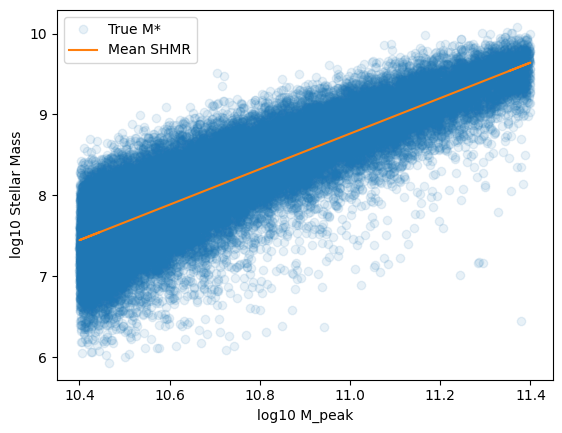

In [12]:
# get deviation from mean SHMR and check that it looks correct
_smass = np.log10(hydro_data['stellar_mass'][mpeak_mask])
_mpeak =  mpeak[mpeak_mask] # already log10

mstar_dev, (m, b) = get_msmhmr(_smass,_mpeak, n_bins=21, mass_bin=mpeak_mass_bin)

_y_pred = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak)
plt.plot(_mpeak, _smass, 'o', alpha=0.1, label='True M*')
plt.plot(_mpeak, _y_pred, '-', label="Mean SHMR")
plt.legend()

plt.xlabel("log10 M_peak")
plt.ylabel("log10 Stellar Mass") 



In [13]:
# get snapshot redshifts and scales
import pandas as pd
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
redshift =metadata['Redshift'].values
scales = 1 / (1 + redshift)

# Preliminary Look at Correlations

In [14]:
# correlation deviation and a12 
from scipy.stats import spearmanr
spearmanr(mstar_dev, hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6223189590001901), pvalue=np.float64(0.0))

In [15]:
# correlation across MAH (deviation and color)
mah = hydro_data['mpeak_mah'][mpeak_mask]
color = gi_color[mpeak_mask]
n_snaps = mah.shape[1]

corrs_mstar_dev = [] 
corrs_color = [] 
for ii in range(n_snaps):
    corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
    corrs_color.append(spearmanr(color, mah[:, ii]).statistic)

corrs_mstar_dev = np.array(corrs_mstar_dev)
corrs_color = np.array(corrs_color)
    

/var/folders/yl/5w7yl6bn1tsc5fjrdtsrsjhh0000gn/T/ipykernel_73103/1328140465.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
/var/folders/yl/5w7yl6bn1tsc5fjrdtsrsjhh0000gn/T/ipykernel_73103/1328140465.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_color.append(spearmanr(color, mah[:, ii]).statistic)


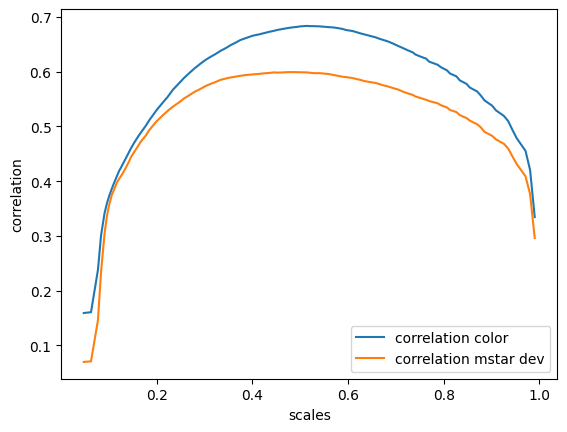

In [55]:
plt.plot(scales, corrs_color, label='correlation color')
plt.plot(scales, corrs_mstar_dev, label='correlation mstar dev')
plt.xlabel('scales')
plt.ylabel('correlation')
plt.legend()

# Train and Apply MultiCAM (Linear)

In [36]:
x = mah
# x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((38956, 100), (38956, 2))

In [37]:
model = MultiCAM(x.shape[1], 2)
model.fit(x,y)

In [38]:
y_pred = model.predict(x)
y_pred.shape

(38956, 2)

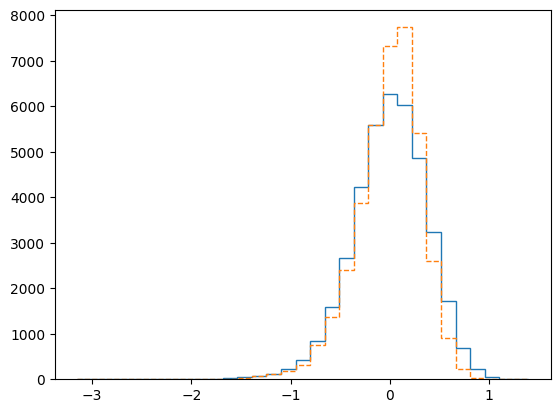

In [39]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--');


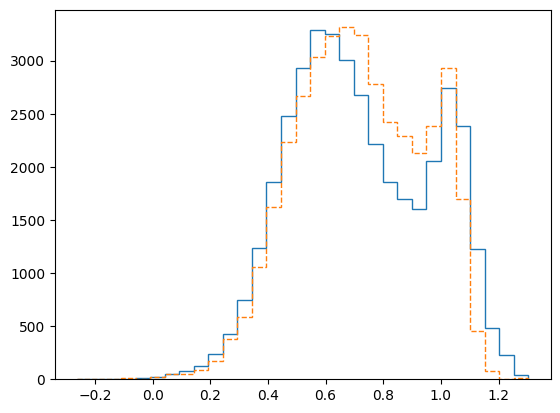

In [40]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--');

In [41]:
# prediction spearmanr (these are what we expect I think)
spearmanr(y_pred[:, 0], y[:, 0]), spearmanr(y_pred[:, 1], y[:, 1])

(SignificanceResult(statistic=np.float64(0.6535441953987556), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7087827302986476), pvalue=np.float64(0.0)))

In [42]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(8624)

(array([535., 525., 528., 492., 455., 439., 444., 407., 413., 421., 380.,
        406., 393., 361., 369., 338., 347., 333., 352., 338., 348.]),
 array([8.20000935, 8.22381783, 8.2476263 , 8.27143478, 8.29524326,
        8.31905174, 8.34286118, 8.36666965, 8.39047813, 8.41428661,
        8.43809509, 8.46190357, 8.48571205, 8.50952053, 8.53332901,
        8.55713749, 8.58094692, 8.6047554 , 8.62856388, 8.65237236,
        8.67618084, 8.69998932]),
 [<matplotlib.patches.Polygon at 0x131575d10>])

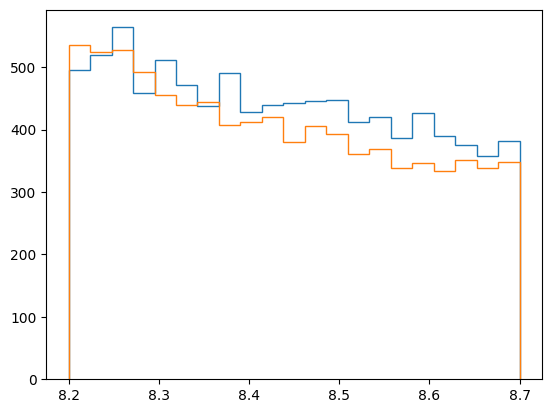

In [43]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step')
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step')

# Sampling

In [44]:
x = mah
# x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((38956, 100), (38956, 2))

In [45]:
model = MultiCamSampling(x.shape[1], 2)
model.fit(x,y)

In [47]:
y_pred = model.sample(x)
y_pred.shape

(38956, 2)

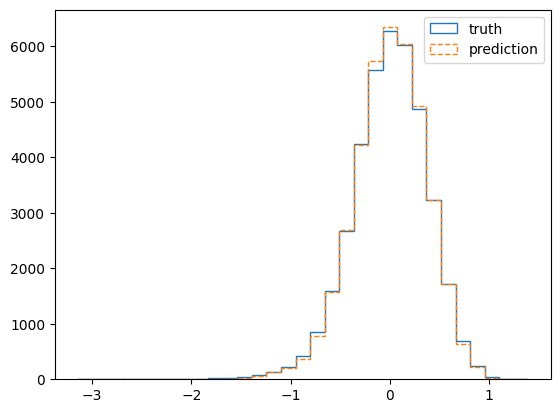

In [54]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step', label='truth')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--', label='prediction');
plt.legend()


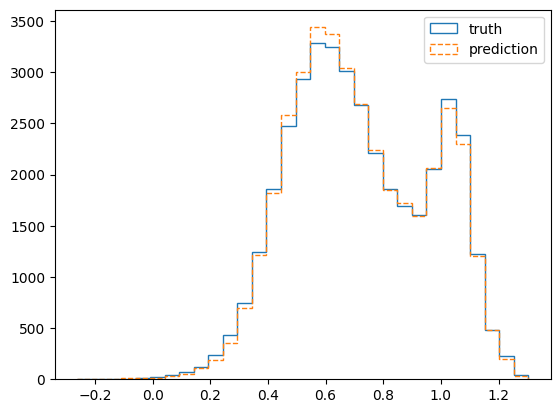

In [53]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step', label='truth')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--', label='prediction');
plt.legend()

In [51]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(8924)

(array([536., 530., 448., 507., 518., 432., 464., 472., 452., 453., 408.,
        443., 382., 381., 371., 421., 358., 362., 323., 331., 332.]),
 array([8.20000935, 8.22381783, 8.2476263 , 8.27143478, 8.29524326,
        8.31905174, 8.34286118, 8.36666965, 8.39047813, 8.41428661,
        8.43809509, 8.46190357, 8.48571205, 8.50952053, 8.53332901,
        8.55713749, 8.58094692, 8.6047554 , 8.62856388, 8.65237236,
        8.67618084, 8.69998932]),
 [<matplotlib.patches.Polygon at 0x1314f2ad0>])

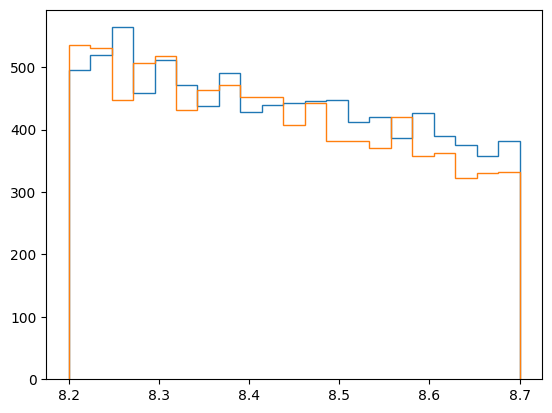

In [52]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step')
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step')